axolotl绘制指标

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'

sns.set_style("whitegrid", rc={"grid.color": ".9", "axes.edgecolor": ".9",})

In [53]:
import pickle as pkl

cluster_edges_path = '../cluster_edges/axolotl.pkl'
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)
cluster_edges

clusters = []
for edge in cluster_edges:
    for cluster in edge:
        if cluster not in clusters:
            clusters.append(cluster)
clusters

['reaEGC', 'rIPC1', 'IMN', 'nptxEX', 'wntEGC', 'mpEX', 'rIPC2', 'dpEX']

In [54]:
base_dir = '/home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs'

In [ ]:
data = 'axolotl/section_selected'

In [56]:
save_dir = f'../figures/{data}'
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [57]:
models_total = ['scvelo', 'scvelo(avg)', 'unitvelo', 'velovae', 'deepvelo(cui)', 'latentvelo', 'latentvelo(lt)', 'velovi', 'topovelo', 'stt', 'stt(vj)', 'velovgi']

绘制CBDir

In [58]:
metric_name = 'cbdir'
basis = 'spatial'
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'latentvelo_annot', 'velovi', 'topovelo_KNN', 'topovelo_Delaunay', 'stt', 'velovgi']
results = {}
for cluster_edge in cluster_edges: 
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {}
    for model in models:
        if model == 'scvelo':
            model_name = 'scvelo_dynamical'
        elif model.startswith('latentvelo'):
            model_name = 'latentvelo'
        elif model.startswith('topovelo'):
            model_name = 'topovelo'
        else:
            model_name = model
        metric_file = f'{base_dir}/{data}/{model}/{metric_name}_{model_name}_velocity_{basis}.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        if edge in metric.keys():
            key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
            result[key] = metric[edge]
        if model == 'stt':
            stt_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_vj_{basis}.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            if edge in stt_metric.keys():
                result['stt(vj)'] = stt_metric[edge]
        if model_name == 'latentvelo':
            ltv_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_spliced_velocity_{basis}.pkl'
            with open(ltv_metric_file, 'rb') as f:
                ltv_metric = pkl.load(f)
            if edge in ltv_metric.keys():
                result[f'{key}(lt)'] = ltv_metric[edge]
    results[edge] = result

In [59]:
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
edge_color_map = dict(zip(results.keys(), colors))

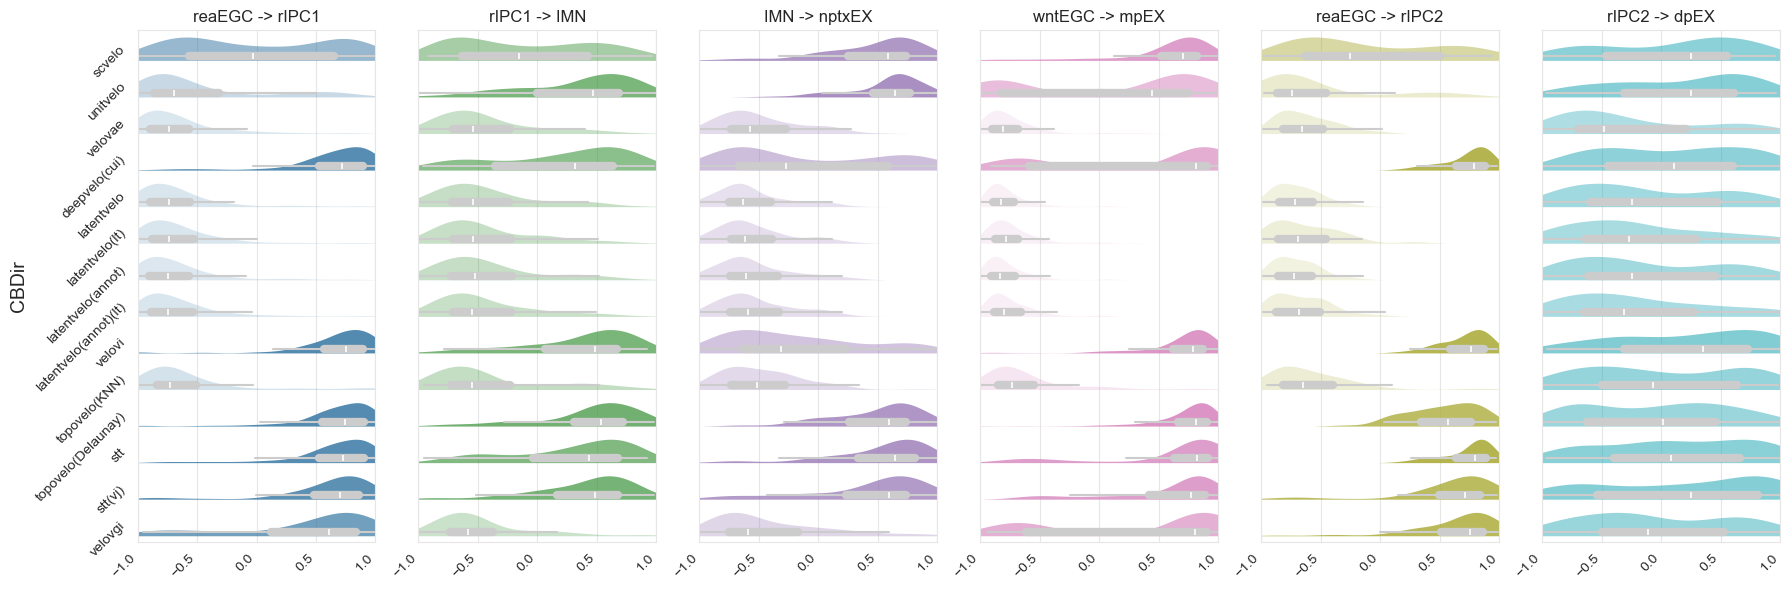

In [60]:
fig, axs = plt.subplots(nrows=1, ncols=len(results), sharex=True, sharey=True, figsize=(18, 6))
for i, (edge, result) in enumerate(results.items()):
    df = pd.DataFrame([(model, value) for model, values in result.items() for value in values], columns=["model", metric_name])
    model_means = {model: np.mean(values) for model, values in result.items()}
    violins = sns.violinplot(
        data=df, 
        x=metric_name, 
        y='model', 
        orient='h', 
        color=edge_color_map[edge], 
        split=True,
        width=0.8, 
        gap=0.2, 
        linewidth=0, 
        density_norm='count', 
        inner_kws=dict(box_width=6, whis_width=1.5, color=".8"), 
        ax=axs[i], 
    )
    for j, model in enumerate(result.keys()):
        violins.collections[j].set_alpha((model_means[model] + 1) / 2)
    axs[i].set_title(edge)
    axs[i].set_xlim(-1, 1)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('CBDir', fontsize=14)
    for label in axs[i].get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    for label in axs[i].get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}.svg')
plt.show()

绘制ICCoh

In [61]:
metric_name = 'inner_cluster_coh'
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'latentvelo_annot', 'velovi', 'topovelo_KNN', 'topovelo_Delaunay', 'stt', 'velovgi']
results = {}
for cluster in clusters:
    result = {}
    for model in models:
        if model == 'scvelo':
            model_name = 'scvelo_dynamical'
        elif model.startswith('latentvelo'):
            model_name = 'latentvelo'
        elif model.startswith('topovelo'):
            model_name = 'topovelo'
        else:
            model_name = model
        metric_file = f'{base_dir}/{data}/{model}/{metric_name}_{model_name}_velocity.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
        result[key] = metric[cluster]
        if model == 'stt':
            stt_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_vj.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            result['stt(vj)'] = stt_metric[cluster]
        if model_name == 'latentvelo':
            ltv_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_spliced_velocity.pkl'
            with open(ltv_metric_file, 'rb') as f:
                ltv_metric = pkl.load(f)
            result[f'{key}(lt)'] = ltv_metric[cluster]
    results[cluster] = result

In [62]:
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
cluster_color_map = dict(zip(results.keys(), colors))

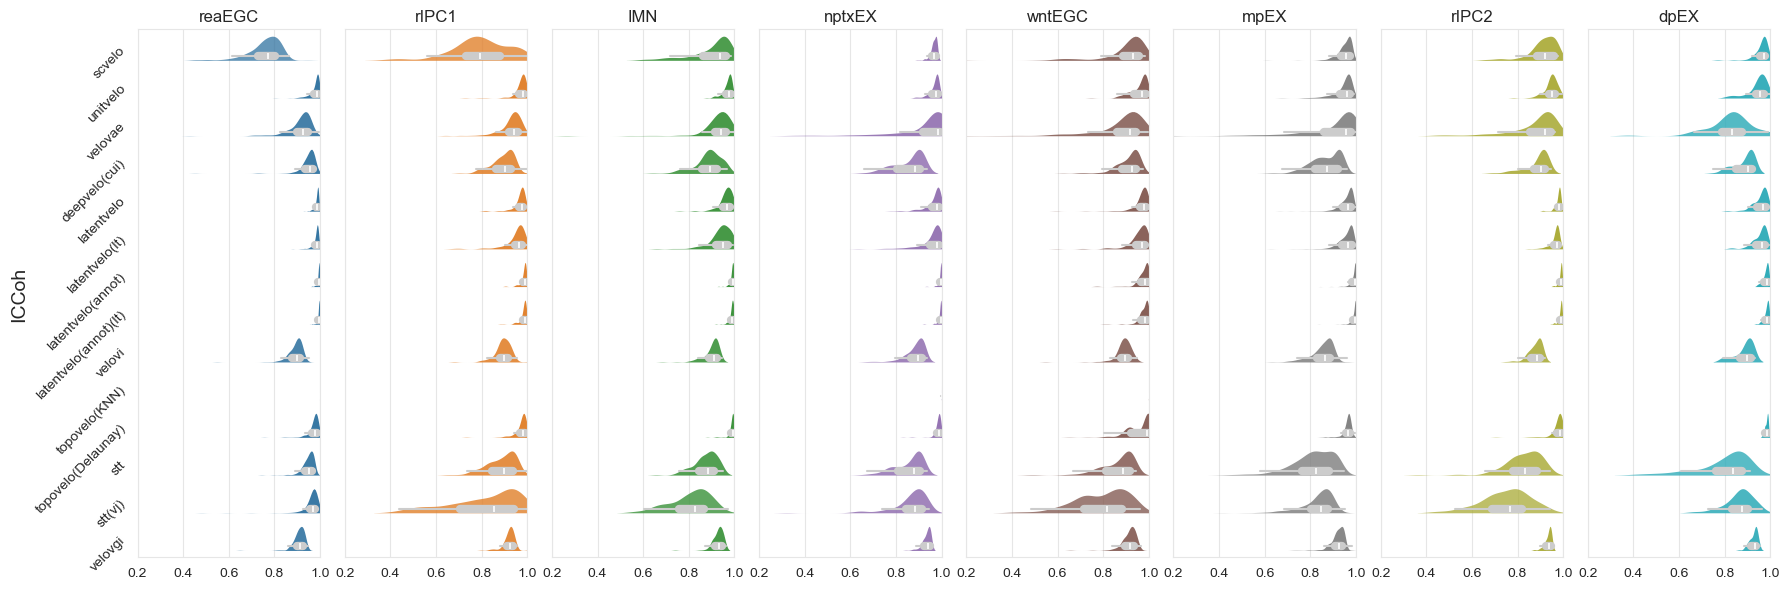

In [63]:
fig, axs = plt.subplots(nrows=1, ncols=len(results), sharex=True, sharey=True, figsize=(18, 6))
for i, (cluster, result) in enumerate(results.items()):
    df = pd.DataFrame([(model, value) for model, values in result.items() for value in values], columns=["model", metric_name])
    model_means = {model: np.mean(values) for model, values in result.items()}
    violins = sns.violinplot(
        data=df, 
        x=metric_name, 
        y='model', 
        orient='h', 
        color=cluster_color_map[cluster], 
        split=True, 
        width=0.8, 
        gap=0.2, 
        linewidth=0, 
        density_norm="count", 
        inner_kws=dict(box_width=6, whis_width=1.5, color=".8"),
        ax = axs[i], 
    )
    for j, model in enumerate(result.keys()):
        violins.collections[j].set_alpha(model_means[model])
    axs[i].set_title(cluster)
    axs[i].set_xlim(0.2, 1)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('ICCoh', fontsize=14)
    # for label in axs[i].get_xticklabels():
    #     label.set_rotation(45)
    #     label.set_ha('right')
    for label in axs[i].get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}.svg')
plt.show()

绘制k-CBDir

In [64]:
import re
import ast

In [65]:
k = 5
basis = 'spatial'
metric_name = 'gen_cbdir_edge'
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'latentvelo_annot', 'velovi', 'topovelo_KNN', 'topovelo_Delaunay', 'stt', 'velovgi']
results = {}
for cluster_edge in cluster_edges:
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {'k': range(1, k+1)}
    for model in models: 
        if model == 'scvelo':
            model_name = 'scvelo_dynamical'
        elif model.startswith('latentvelo'):
            model_name = 'latentvelo'
        elif model.startswith('topovelo'):
            model_name = 'topovelo'
        else:
            model_name = model
        metric_file = f'{base_dir}/{data}/{model}/metric_redo.csv'
        if not os.path.exists(metric_file):
            metric_file = f'{base_dir}/{data}/{model}/metric.csv'
        metric = pd.read_csv(metric_file, index_col=0)
        idx_name = f'{metric_name}_{model_name}_velocity_{basis}_{edge}'
        if idx_name in metric.index:
            cbdir = metric.loc[metric.index == idx_name, '0'].values[0]
            if 'nan' not in cbdir:
                cbdir = re.sub(r'(?<=\d)\s+(?=\d|[-])', ', ', cbdir)
                cbdir = ast.literal_eval(cbdir)
                key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
                result[key] = cbdir
        if model == 'stt': 
            stt_idx_name = f'{metric_name}_vj_{basis}_{edge}'
            if stt_idx_name in metric.index:
                cbdir = metric.loc[metric.index == stt_idx_name, '0'].values[0]
                if 'nan' not in cbdir:
                    cbdir = re.sub(r'(?<=\d)\s+(?=\d|[-])', ', ', cbdir)
                    cbdir = ast.literal_eval(cbdir)
                    result['stt(vj)'] = cbdir
        if model_name == 'latentvelo':
            ltv_idx_name = f'{metric_name}_spliced_velocity_{basis}_{edge}'
            if ltv_idx_name in metric.index:
                cbdir = metric.loc[metric.index == ltv_idx_name, '0'].values[0]
                if 'nan' not in cbdir:
                    cbdir = re.sub(r'\s+', ', ', cbdir)
                    cbdir = ast.literal_eval(cbdir)
                    result[f'{key}(lt)'] = cbdir
    results[edge] = result
results

{'reaEGC -> rIPC1': {'k': range(1, 6),
  'scvelo': [0.01109992, 0.07131744, 0.14379961, 0.20529942, 0.24536311],
  'unitvelo': [-0.4696084, -0.44801068, -0.38966565, -0.32241817, -0.28003454],
  'velovae': [-0.65169635, -0.58598156, -0.49095054, -0.40246276, -0.33839823],
  'deepvelo(cui)': [0.63542458, 0.57756048, 0.5487398, 0.54344059, 0.53178702],
  'latentvelo': [-0.64855301,
   -0.57967068,
   -0.48703962,
   -0.40337367,
   -0.34103362],
  'latentvelo(lt)': [-0.64560864,
   -0.57750046,
   -0.48429945,
   -0.40113369,
   -0.34044529],
  'latentvelo(annot)': [-0.66417656,
   -0.59486704,
   -0.50015017,
   -0.41284004,
   -0.34868207],
  'latentvelo(annot)(lt)': [-0.65068708,
   -0.57930412,
   -0.48396041,
   -0.39778727,
   -0.33441161],
  'velovi': [0.67601632, 0.63661392, 0.61254605, 0.60562478, 0.59361945],
  'topovelo(KNN)': [-0.58138756,
   -0.50355973,
   -0.4033974,
   -0.31779377,
   -0.25421691],
  'topovelo(Delaunay)': [0.66372657,
   0.63924872,
   0.62122868,
   0.61

创建自定义调色盘

In [66]:
colors = {
    'scvelo': plt.cm.Set2(0 / 8),
    'unitvelo': plt.cm.Set2(1 / 8),
    'velovi': plt.cm.Set2(2 / 8),
    'velovae': plt.cm.Set2(3 / 8),
    'stt': plt.cm.Set2(4 / 8),
    'stt(vj)': plt.cm.Set2(4 / 8),
    'topovelo(KNN)': plt.cm.Set2(6 / 8),
    'topovelo(Delaunay)': plt.cm.Set3(1 / 12),
    'velovae(prior)': plt.cm.Set3(7 / 12),
    'deepvelo(cui)': plt.cm.Set3(8 / 12),
    'latentvelo(prior)': plt.cm.Set3(10 / 12),
    'latentvelo': plt.cm.tab20b(12 / 20),
    'latentvelo(batch)': plt.cm.tab20b(15 / 20),
    'latentvelo(annot)': plt.cm.tab20c(12 / 20),
    'latentvelo(annot)(batch)': plt.cm.tab20c(15 / 20),
    'latentvelo(prior)(lt)': plt.cm.Set3(10 / 12),
    'latentvelo(lt)': plt.cm.tab20b(12 / 20),
    'latentvelo(batch)(lt)': plt.cm.tab20b(15 / 20),
    'latentvelo(annot)(lt)': plt.cm.tab20c(12 / 20),
    'latentvelo(annot)(batch)(lt)': plt.cm.tab20c(15 / 20),
    'velovgi': plt.cm.tab20c(0 / 20),
    'velovgi(batch)': plt.cm.tab20c(3 / 20),
}
line_styles = {
    'scvelo': (1, 0),  # '-' 实线
    'unitvelo': (1, 0),  # '-' 实线
    'velovi': (1, 0),  # '-' 实线
    'velovae': (1, 0),  # '-' 实线
    'stt': (1, 0),  # '-' 实线
    'stt(vj)': (4, 2),  # '--' 虚线
    'topovelo(KNN)': (1, 0),  # '-' 实线
    'topovelo(Delaunay)': (1, 0),  # '-' 实线
    'velovae(prior)': (1, 0),  # '-' 实线
    'deepvelo(cui)': (1, 0),  # '-' 实线
    'latentvelo(prior)': (1, 0),  # '-' 实线
    'latentvelo': (1, 0),  # '-' 实线
    'latentvelo(batch)': (1, 0),  # '-' 实线
    'latentvelo(annot)': (1, 0),  # '-' 实线
    'latentvelo(annot)(batch)': (1, 0),  # '-' 实线
    'latentvelo(prior)(lt)': (4, 2),  # '--' 虚线
    'latentvelo(lt)': (4, 2),  # '--' 虚线
    'latentvelo(batch)(lt)': (4, 2),  # '--' 虚线
    'latentvelo(annot)(lt)': (4, 2),  # '--' 虚线
    'latentvelo(annot)(batch)(lt)': (4, 2),  # '--' 虚线
    'velovgi': (1, 0),  # '-' 实线
    'velovgi(batch)': (1, 0),  # '-' 实线
}
markers = {
    'scvelo': 's',
    'unitvelo': 's',
    'velovi': 's',
    'velovae': 's',
    'stt': 's',
    'stt(vj)': 'd',
    'topovelo(KNN)': 's',
    'topovelo(Delaunay)': 's',
    'velovae(prior)': 's',
    'deepvelo(cui)': 's',
    'latentvelo(prior)': 's',
    'latentvelo': 's',
    'latentvelo(batch)': 's',
    'latentvelo(annot)': 's',
    'latentvelo(annot)(batch)': 's',
    'latentvelo(prior)(lt)': 'd',
    'latentvelo(lt)': 'd',
    'latentvelo(batch)(lt)': 'd',
    'latentvelo(annot)(lt)': 'd',
    'latentvelo(annot)(batch)(lt)': 'd',
    'velovgi': 's',
    'velovgi(batch)': 's',
}

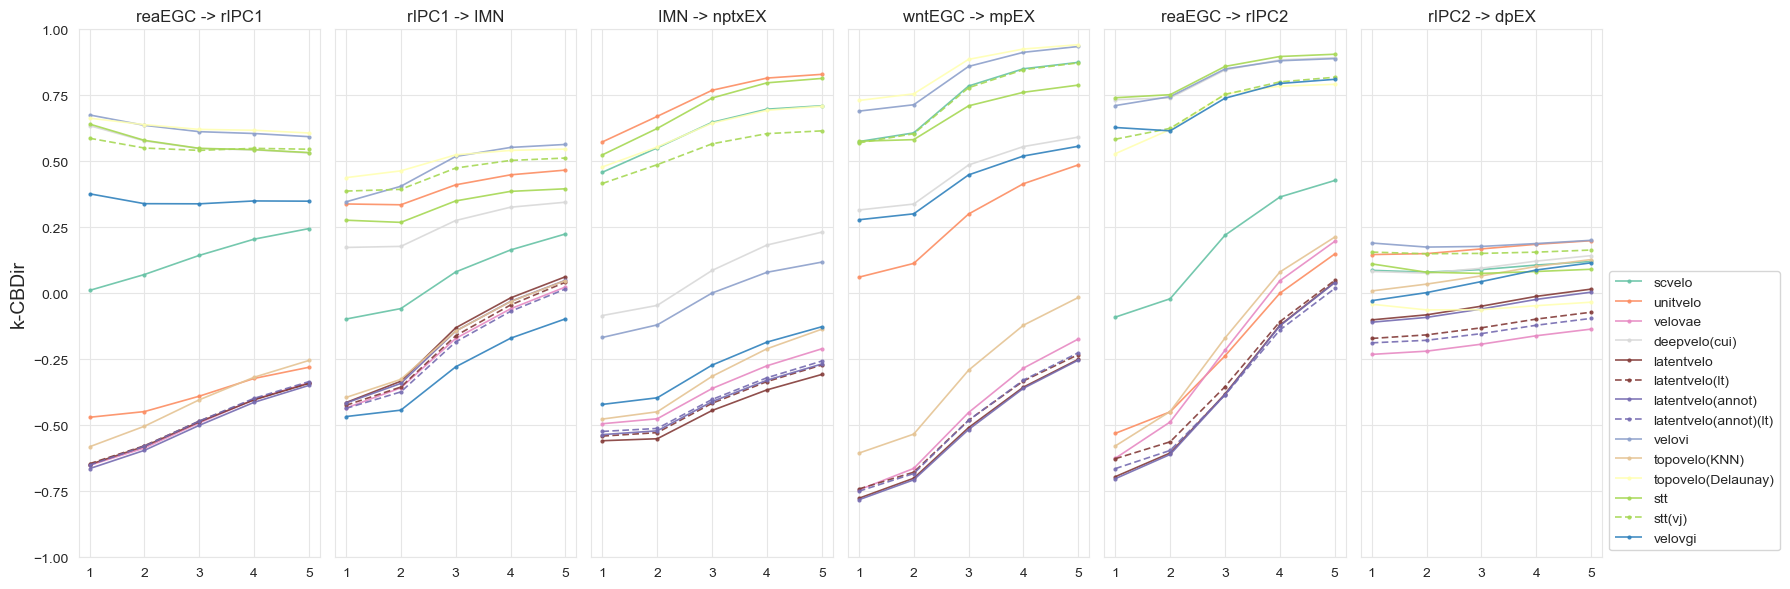

In [67]:
fig, axs = plt.subplots(nrows=1, ncols=len(results), sharex=True, sharey=True, figsize=(18, 6))
for i, (edge, result) in enumerate(results.items()):
    df = pd.DataFrame(result).melt(id_vars=['k'], var_name='model', value_name=metric_name)
    sns.lineplot(
        data=df, 
        x='k', 
        y=metric_name, 
        hue='model', 
        palette=colors, 
        style='model', 
        dashes=line_styles, 
        ax=axs[i], 
        linewidth=1.2,
        alpha=0.9,
        marker='o',
        markersize=3,
        markeredgewidth=0
    )
    axs[i].set_title(edge)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('k-CBDir', fontsize=14)
    axs[i].set_ylim(-1, 1)
    axs[i].get_legend().remove()

handles, labels = axs[0].get_legend_handles_labels()
plt.legend(handles, labels, loc='lower left', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}.svg', bbox_inches='tight')
plt.show()

Time Score & Spatial Time Consist

In [68]:
metric_name = 'time_score_edge'
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'latentvelo_annot', 'velovi', 'topovelo_KNN', 'topovelo_Delaunay', 'velovgi']
results = {}
for cluster_edge in cluster_edges:
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {}
    for model in models: 
        if model == 'scvelo':
            model_name = 'scvelo_dynamical'
        elif model.startswith('latentvelo'):
            model_name = 'latentvelo'
        elif model.startswith('topovelo'):
            model_name = 'topovelo'
        else:
            model_name = model
        metric_file = f'{base_dir}/{data}/{model}/metric_redo.csv'
        if not os.path.exists(metric_file):
            metric_file = f'{base_dir}/{data}/{model}/metric.csv'
        metric = pd.read_csv(metric_file, index_col=0)
        if model_name not in ['velovi', 'velovgi']:
            tkey = 'pred_t'
            idx_name = f'{metric_name}_{tkey}_{edge}'
            if idx_name in metric.index:
                t_score = float(metric.loc[metric.index == idx_name, '0'].values[0])
                key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
                result[key] = t_score
        if model_name in ['scvelo_dynamical', 'velovi', 'velovgi']:
            t_gene_key = 'fit_t'
            idx_name = f'{metric_name}_{t_gene_key}_{edge}'
            if idx_name in metric.index:
                t_score = float(metric.loc[metric.index == idx_name, '0'].values[0])
                key = f'{model}(avg)' if model == 'scvelo' else model
                result[key] = t_score
    results[edge] = result
results

{'reaEGC -> rIPC1': {'scvelo': 0.018252567394094994,
  'scvelo(avg)': 0.14435574454428754,
  'unitvelo': 0.9583400192554558,
  'velovae': 0.018533376123234916,
  'deepvelo(cui)': 0.9924382220795892,
  'latentvelo': 0.0064786585365853655,
  'latentvelo(annot)': 0.005556001283697047,
  'velovi': 0.32547737483953787,
  'topovelo(KNN)': 0.19879252246469833,
  'topovelo(Delaunay)': 0.9798018292682927,
  'velovgi': 0.17470314505776638},
 'rIPC1 -> IMN': {'scvelo': 0.3959654407102093,
  'scvelo(avg)': 0.3428582752060875,
  'unitvelo': 0.8206246036778694,
  'velovae': 0.27726696258719086,
  'deepvelo(cui)': 0.8476537729866835,
  'latentvelo': 0.24464965123652505,
  'latentvelo(annot)': 0.2456404565630945,
  'velovi': 0.5114933417882055,
  'topovelo(KNN)': 0.34678186429930247,
  'topovelo(Delaunay)': 0.734147114774889,
  'velovgi': 0.6114061509194674},
 'IMN -> nptxEX': {'scvelo': 0.6934738955823293,
  'scvelo(avg)': 0.3820281124497992,
  'unitvelo': 0.7592034805890228,
  'velovae': 0.058902275

In [69]:
metric_name = 'spatial_time_consist'
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'latentvelo_annot', 'velovi', 'topovelo_KNN', 'topovelo_Delaunay', 'velovgi']
result_spatial_time_consist = {}
for model in models: 
    if model == 'scvelo':
        model_name = 'scvelo_dynamical'
    elif model.startswith('latentvelo'):
        model_name = 'latentvelo'
    elif model.startswith('topovelo'):
        model_name = 'topovelo'
    else:
        model_name = model
    metric_file = f'{base_dir}/{data}/{model}/metric_redo.csv'
    if not os.path.exists(metric_file):
        metric_file = f'{base_dir}/{data}/{model}/metric.csv'
    metric = pd.read_csv(metric_file, index_col=0)
    if model_name not in ['velovi', 'velovgi']:
        tkey = 'pred_t'
        idx_name = f'{metric_name}_{tkey}'
        spatial_time_consist = float(metric.loc[metric.index == idx_name, '0'].values[0])
        key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
        result_spatial_time_consist[key] = spatial_time_consist
    if model_name in ['scvelo_dynamical', 'velovi', 'velovgi']:
        t_gene_key = 'fit_t'
        idx_name = f'{metric_name}_{t_gene_key}'
        spatial_time_consist = float(metric.loc[metric.index == idx_name, '0'].values[0])
        key = f'{model}(avg)' if model == 'scvelo' else model
        result_spatial_time_consist[key] = spatial_time_consist
result_spatial_time_consist

{'scvelo': 0.667751202050188,
 'scvelo(avg)': 0.26178692651981067,
 'unitvelo': 0.7494564056396484,
 'velovae': 0.782609444977117,
 'deepvelo(cui)': 0.7643311182657877,
 'latentvelo': 0.8256289800008138,
 'latentvelo(annot)': 0.8031305948893229,
 'velovi': 0.3722977638244629,
 'topovelo(KNN)': 0.8100987116495768,
 'topovelo(Delaunay)': 0.8356304804484049,
 'velovgi': 0.20326528549194336}

In [70]:
color_map = plt.cm.Oranges

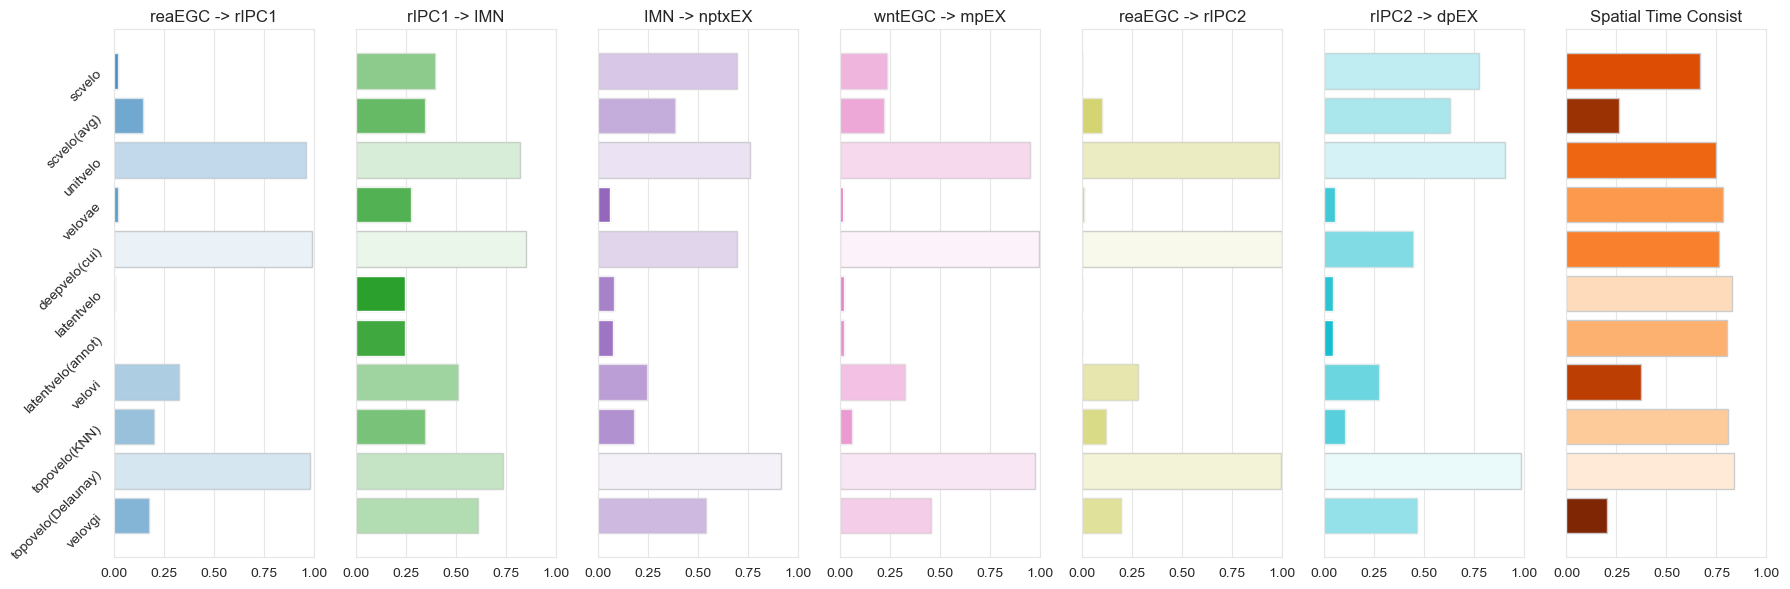

In [71]:
fig, axs = plt.subplots(nrows=1, ncols=len(results) + 1, sharex=True, sharey=True, figsize=(18, 6))
metric1_name = 'time_score_edge'
for i, (edge, result) in enumerate(results.items()):
    df = pd.DataFrame(list(result.items()), columns=['model', metric1_name])
    sns.barplot(data=df, x=metric1_name, y='model', ax=axs[i], orient='h', color='white', edgecolor='.8', linewidth=1)
    df['rank'] = df[metric1_name].rank(ascending=False)
    for j, (model, value, rank) in enumerate(zip(df['model'], df[metric1_name], df['rank'])):
        axs[i].barh(model, value, color=edge_color_map[edge], alpha=rank / len(df['rank']))
    axs[i].set_title(edge)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_xlim(0, 1)
    for label in axs[i].get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
i = i + 1
metric2_name = 'spatial_time_consist'
df = pd.DataFrame(list(result_spatial_time_consist.items()), columns=['model', metric2_name])
sns.barplot(data=df, x=metric2_name, y='model', ax=axs[i], orient='h')
df['rank'] = df[metric2_name].rank(ascending=False)
for j, (model, value, rank) in enumerate(zip(df['model'], df[metric2_name], df['rank'])):
    axs[i].barh(model, value, color=color_map(rank / (len(df['rank'] + 1))), edgecolor='.8', linewidth=1)
axs[i].set_title(metric2_name.replace('_', ' ').title())
axs[i].set_xlabel('')
axs[i].set_ylabel('')
axs[i].set_xlim(0, 1)
for label in axs[i].get_yticklabels():
    label.set_rotation(45)
    label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/{metric1_name}_{metric2_name}.svg', bbox_inches='tight')
plt.show()

Velocity Consist & Spatial Velocity Consist

In [72]:
metric_names = ('velocity_consistency', 'spatial_velo_consist')
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'latentvelo_annot', 'velovi', 'topovelo_KNN', 'topovelo_Delaunay', 'stt', 'velovgi']
results = {}
for model in models:
    if model == 'scvelo':
        model_name = 'scvelo_dynamical'
    elif model.startswith('latentvelo'):
        model_name = 'latentvelo'
    elif model.startswith('topovelo'):
        model_name = 'topovelo'
    else:
        model_name = model
    result = {}
    for metric_name in metric_names:
        metric_file = f'{base_dir}/{data}/{model}/{metric_name}_{model_name}_velocity.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        result[metric_name] = metric
    key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
    results[key] = result
    if model == 'stt':
        result = {}
        for metric_name in metric_names:
            stt_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_vj.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            result[metric_name] = stt_metric
        results['stt(vj)'] = result
    if model_name == 'latentvelo':
        result = {}
        for metric_name in metric_names:
            ltv_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_spliced_velocity.pkl'
            with open(ltv_metric_file, 'rb') as f:
                ltv_metric = pkl.load(f)
            result[metric_name] = ltv_metric
        results[f'{key}(lt)'] = result
results

{'scvelo': {'velocity_consistency': [0.9105091680726698,
   0.9793994158853678,
   0.9717484859856109,
   0.8121802695208197,
   0.9620407983471608,
   0.9257135674613489,
   0.7146382125824802,
   0.7742446428853789,
   0.9690719565839924,
   0.9673806972135085,
   0.7382964833894291,
   0.9432614380266648,
   0.754304851248899,
   0.9658382140890854,
   0.7223446595353932,
   0.8714231492610107,
   0.9136115448551856,
   0.9588506407581758,
   0.9599942833005232,
   0.9198783650152981,
   0.9190173135110336,
   0.9619481131749313,
   0.8268949808080791,
   0.9677393863153881,
   0.6755154208003266,
   0.9020368961639188,
   0.9727401411272112,
   0.9794840891446676,
   0.7991244818210694,
   0.7627707332653522,
   0.9410353277072093,
   0.9692801286894814,
   0.9776372166753703,
   0.7641612313151355,
   0.9527498651579237,
   0.779108034590999,
   0.9665482163028384,
   0.7484183951341395,
   0.9571937282386945,
   0.968700097143971,
   0.7931731951669485,
   0.963967630916611,
   0

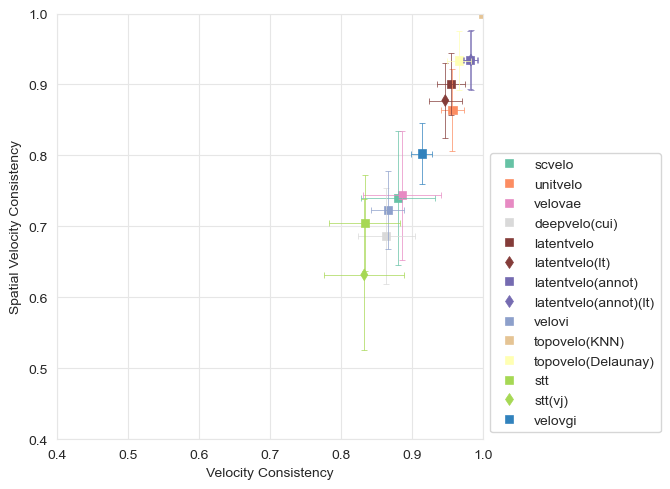

In [73]:
keys = []
velocity_consistency_means = []
spatial_velo_consist_means = []
velocity_consistency_stds = []
spatial_velo_consist_stds = []
for key, value in results.items():
    keys.append(key)
    velocity_consistency_means.append(np.mean(value['velocity_consistency']))
    spatial_velo_consist_means.append(np.mean(value['spatial_velo_consist']))
    velocity_consistency_stds.append(np.std(value['velocity_consistency']))
    spatial_velo_consist_stds.append(np.std(value['spatial_velo_consist']))
df = pd.DataFrame({'model': keys, 'velocity_consistency': velocity_consistency_means, 'spatial_velo_consist': spatial_velo_consist_means})
plt.figure(figsize=(7, 5))
plt.xlim(0.4, 1)
plt.ylim(0.4, 1)
plt.gca().set_aspect('equal')
sns.scatterplot(data=df, x='velocity_consistency', y='spatial_velo_consist', hue='model', palette=colors, style='model', markers=markers, edgecolor=None)
plt.xlabel('Velocity Consistency')
plt.ylabel('Spatial Velocity Consistency')
for i in range(df.shape[0]):
    plt.errorbar(df['velocity_consistency'][i], df['spatial_velo_consist'][i], xerr=0.5*velocity_consistency_stds[i], yerr=0.5*spatial_velo_consist_stds[i], fmt='none',
                  color=colors[df['model'][i]], capsize=2, capthick=0.5, elinewidth=0.5)
plt.legend(loc='lower left', bbox_to_anchor=(1, 0))
plt.tight_layout()
plt.savefig(f'{save_dir}/{"_".join(metric_names)}.svg')
plt.show()